**Aulas 10 - Redução de Dimensionalidade**

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/dim_reduction`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Intuição Geométrica dos Dados

## Projeção

**Os Dados podem ser projetados em Dimensões Menores**

Vamos gerar um pequeno conjunto de dados em 3D. Ele possui um formato oval, rotacionado no espaço tridimensional, com pontos distribuídos de forma desigual e com bastante ruído

In [5]:
# Gerando um Conjunto de Dados 3D

import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

Plotando o conjunto de dados em 3D, juntamente com o plano de projeção.

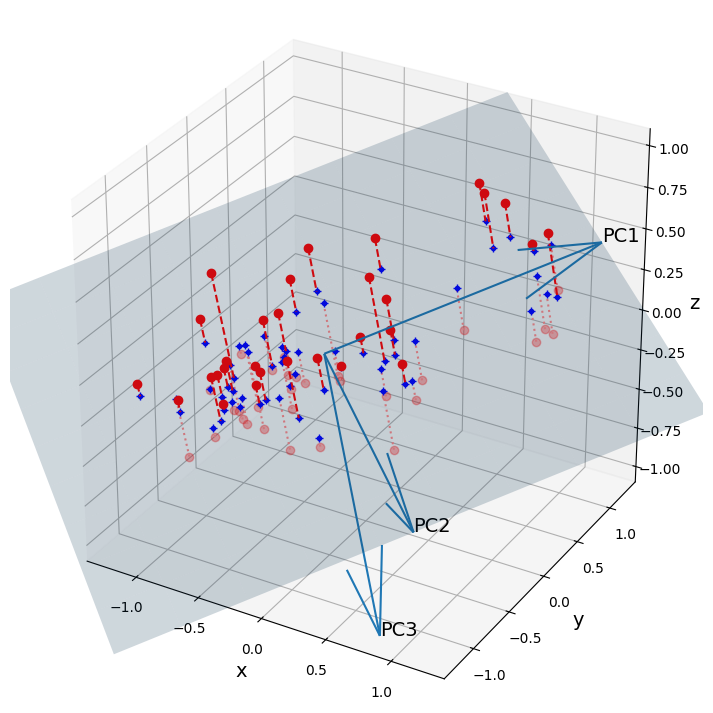

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Treinando o PCA
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)
X3D_inv = pca.inverse_transform(X2D)

# Componentes principais
v1 = pca.components_[0]  # PC1
v2 = pca.components_[1]  # PC2
mean = pca.mean_ # Média


# Plano PCA (PC1 + PC2)
u, v = np.meshgrid(np.linspace(-2, 2, 10),
                   np.linspace(-2, 2, 10))

plane = mean + u[..., np.newaxis]*v1 + v[..., np.newaxis]*v2

x_plane = plane[:, :, 0]
y_plane = plane[:, :, 1]
z_plane = plane[:, :, 2]


# PC3 (normal ao plano)
pc3 = np.cross(v1, v2)
pc3 = pc3 / np.linalg.norm(pc3)


# Separar pontos (acima/abaixo do plano)
X3D_above = X[X[:, 2] >= X3D_inv[:, 2]]
X3D_below = X[X[:, 2] < X3D_inv[:, 2]]


# 6. Plot
fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection="3d")

# pontos abaixo do plano
ax.plot(X3D_below[:, 0], X3D_below[:, 1], X3D_below[:, 2], "ro", alpha=0.3)
for i in range(m):
    if X[i, 2] < X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], ":", color="#F88")


# plano PCA
ax.plot_surface(x_plane, y_plane, z_plane, alpha=0.2)

# pontos projetados
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b+")
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b.")


# linhas de projeção (acima)
for i in range(m):
    if X[i, 2] >= X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], "r--")

# pontos acima do plano
ax.plot(X3D_above[:, 0], X3D_above[:, 1], X3D_above[:, 2], "ro")


# Eixos PCA (PC1, PC2, PC3)
scale = 2.0

exibirEixosPC = True

if exibirEixosPC :
  # PC1
  ax.quiver(mean[0], mean[1], mean[2],
            v1[0], v1[1], v1[2],
            length=scale)

  # PC2
  ax.quiver(mean[0], mean[1], mean[2],
            v2[0], v2[1], v2[2],
            length=scale)

  # PC3 (normal ao plano)
  ax.quiver(mean[0], mean[1], mean[2],
            pc3[0], pc3[1], pc3[2],
            length=scale)

  # rótulos
  ax.text(mean[0] + v1[0]*scale,
          mean[1] + v1[1]*scale,
          mean[2] + v1[2]*scale,
          "PC1")

  ax.text(mean[0] + v2[0]*scale,
          mean[1] + v2[1]*scale,
          mean[2] + v2[2]*scale,
          "PC2")

  ax.text(mean[0] + pc3[0]*scale,
          mean[1] + pc3[1]*scale,
          mean[2] + pc3[2]*scale,
          "PC3")

# 8. Ajustes de eixo
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_xlim([-1.4, 1.4])
ax.set_ylim([-1.4, 1.4])
ax.set_zlim([-1.1, 1.1])

# evita distorção (ESSENCIAL)
ax.set_box_aspect([1,1,1])

#plt.title("PCA: Plano (PC1+PC2) + Eixos PC1, PC2, PC3")
save_fig("dataset_3d_plot", tight_layout=False)
plt.show()

Após a Redução de Dimensionalidade, temos os dados com sua visualização em 2D

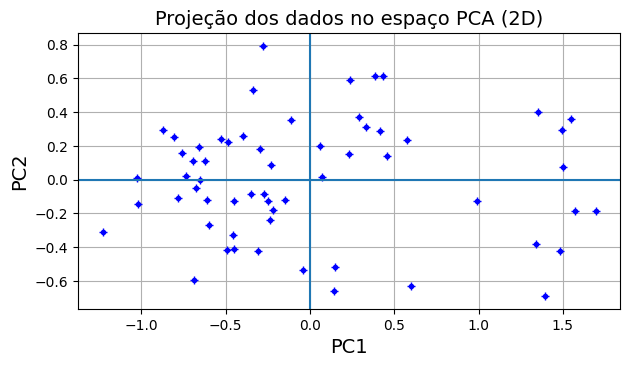

In [49]:
# Plot 2D (espaço PCA)
plt.figure(figsize=(7, 7))

plt.plot(X2D[:, 0], X2D[:, 1], "b+")
plt.plot(X2D[:, 0], X2D[:, 1], "b.")


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projeção dos dados no espaço PCA (2D)")

# linhas de referência
plt.axhline(0)
plt.axvline(0)

# manter proporção correta
plt.gca().set_aspect('equal', adjustable='box')

plt.grid(True)
plt.show()

## Manifold

**Agora teremos alguns exemplos utilizando o dataset SwissRoll**

In [10]:
from sklearn.datasets import make_swiss_roll

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

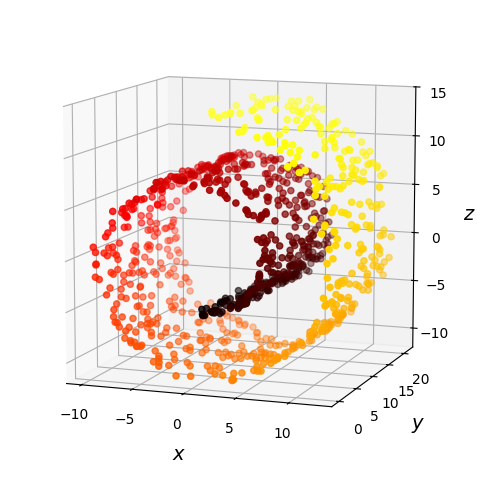

In [11]:
from matplotlib.colors import ListedColormap

def set_xyz_axes(ax, axes):
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_xlabel("$x$", labelpad=8, rotation=0)
    ax.set_ylabel("$y$", labelpad=8, rotation=0)
    ax.set_zlabel("$z$", labelpad=8, rotation=0)
    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])
    ax.set_box_aspect([1,1,1])

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=darker_hot)
ax.view_init(10, -70)
set_xyz_axes(ax, axes)
save_fig("swiss_roll_plot")
plt.show()

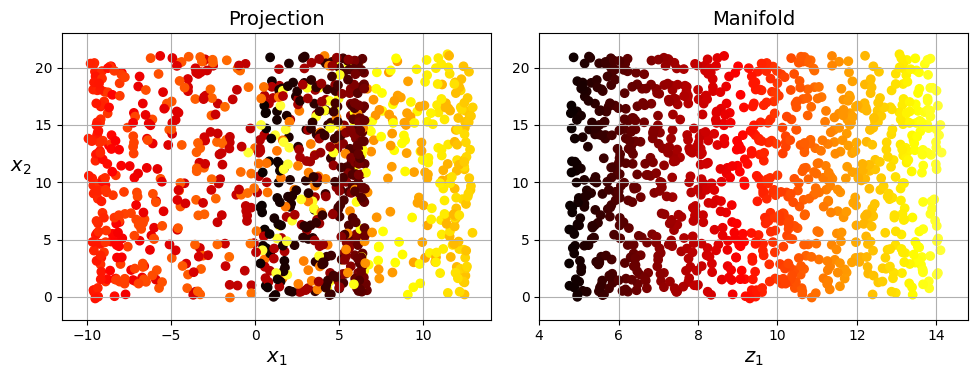

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.scatter(X_swiss[:, 0], X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis(axes[:4])
plt.title("Projection")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", labelpad=10, rotation=0)
plt.grid(True)

plt.subplot(122)
plt.scatter(t, X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis([4, 14.8, axes[2], axes[3]])
plt.title("Manifold")
plt.xlabel("$z_1$")
plt.grid(True)

save_fig("squished_swiss_roll_plot")
plt.show()

Outros exemplos de Manifold utilizando o SwissRoll, mudando a hipótese aplicada

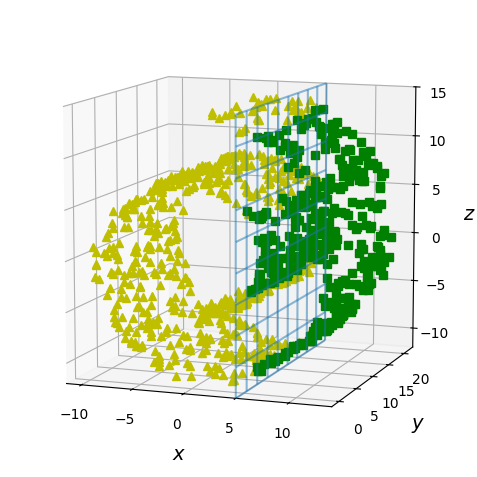

In [13]:
axes = [-11.5, 14, -2, 23, -12, 15]
x2s = np.linspace(axes[2], axes[3], 10)
x3s = np.linspace(axes[4], axes[5], 10)
x2, x3 = np.meshgrid(x2s, x3s)

positive_class = X_swiss[:, 0] > 5
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot_wireframe(5, x2, x3, alpha=0.5)
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
set_xyz_axes(ax, axes)
save_fig("manifold_decision_boundary_plot1")
plt.show()



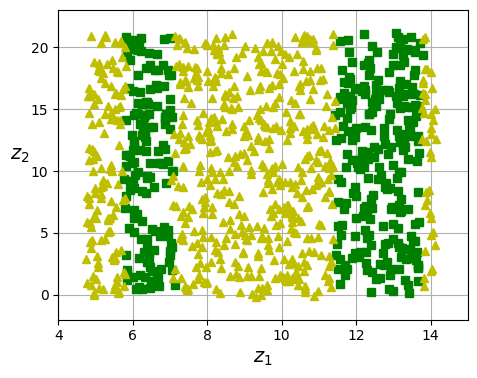

In [14]:
fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
save_fig("manifold_decision_boundary_plot2")
plt.show()

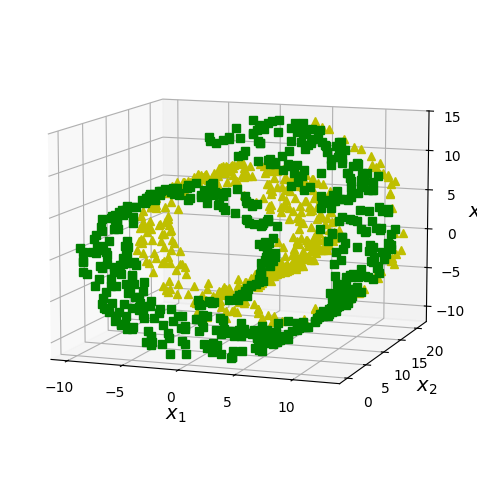

In [15]:
positive_class = 2 * (t[:] - 4) > X_swiss[:, 1]
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel("$x_1$", rotation=0)
ax.set_ylabel("$x_2$", rotation=0)
ax.set_zlabel("$x_3$", rotation=0)
ax.set_xlim(axes[0:2])
ax.set_ylim(axes[2:4])
ax.set_zlim(axes[4:6])
save_fig("manifold_decision_boundary_plot3")
plt.show()

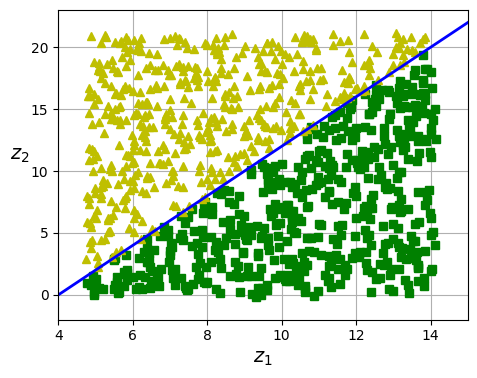

In [16]:
fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.plot([4, 15], [0, 22], "b-", linewidth=2)
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
save_fig("manifold_decision_boundary_plot4")
plt.show()

### FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

#PCA (Análise de Componente Principal)

## Intuição do PCA

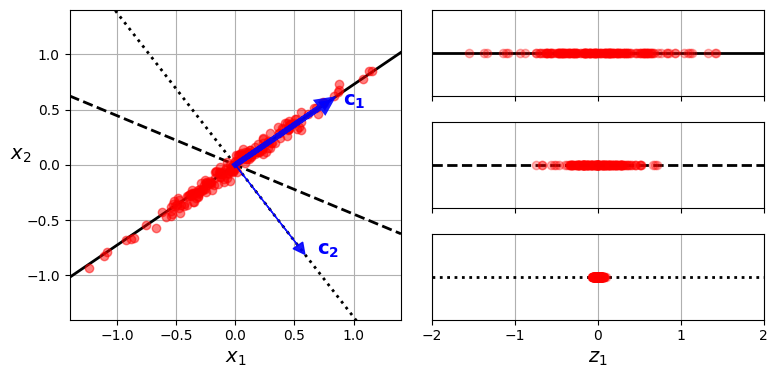

In [17]:
angle = np.pi / 5
stretch = 5
m = 200

np.random.seed(3)
X_line = np.random.randn(m, 2) / 10
X_line = X_line @ np.array([[stretch, 0], [0, 1]])  # stretch
X_line = X_line @ [[np.cos(angle), np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]]  # rotate

u1 = np.array([np.cos(angle), np.sin(angle)])
u2 = np.array([np.cos(angle - 2 * np.pi / 6), np.sin(angle - 2 * np.pi / 6)])
u3 = np.array([np.cos(angle - np.pi / 2), np.sin(angle - np.pi / 2)])

X_proj1 = X_line @ u1.reshape(-1, 1)
X_proj2 = X_line @ u2.reshape(-1, 1)
X_proj3 = X_line @ u3.reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.subplot2grid((3, 2), (0, 0), rowspan=3)
plt.plot([-1.4, 1.4], [-1.4 * u1[1] / u1[0], 1.4 * u1[1] / u1[0]], "k-",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u2[1] / u2[0], 1.4 * u2[1] / u2[0]], "k--",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u3[1] / u3[0], 1.4 * u3[1] / u3[0]], "k:",
         linewidth=2)
plt.plot(X_line[:, 0], X_line[:, 1], "ro", alpha=0.5)
plt.arrow(0, 0, u1[0], u1[1], head_width=0.1, linewidth=4, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.arrow(0, 0, u3[0], u3[1], head_width=0.1, linewidth=1, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.text(u1[0] + 0.1, u1[1] - 0.05, r"$\mathbf{c_1}$", color="blue")
plt.text(u3[0] + 0.1, u3[1], r"$\mathbf{c_2}$", color="blue")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.axis([-1.4, 1.4, -1.4, 1.4])
plt.grid()

plt.subplot2grid((3, 2), (0, 1))
plt.plot([-2, 2], [0, 0], "k-", linewidth=2)
plt.plot(X_proj1[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (1, 1))
plt.plot([-2, 2], [0, 0], "k--", linewidth=2)
plt.plot(X_proj2[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (2, 1))
plt.plot([-2, 2], [0, 0], "k:", linewidth=2)
plt.plot(X_proj3[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.axis([-2, 2, -1, 1])
plt.xlabel("$z_1$")
plt.grid()

save_fig("pca_best_projection_plot")
plt.show()

## Componentes Principais

### Para quem quiser se aprofundar nas questões matemáticas do cálculo dos Componentes Principais

Aqui utilizaremos o Conjunto de Dados 3D gerado no início do Notebook, na explicação inicial de Projeção.

Abaixo serão calculados os Componentes Principais para este Dataset através da função `np.linalg.svd(X_centered)`.

Importante ressaltar, que para a função `np.linalg.svd(X_centered)` ter o resultado esperado, é necessário que os dados estejam centralizados.

In [18]:
import numpy as np

X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

In [19]:
c1

array([0.67857588, 0.70073508, 0.22023881])

In [20]:
c2

array([-0.72817329,  0.6811147 ,  0.07646185])

Observação: em princípio, o algoritmo de fatoração SVD retorna três matrizes, U, Σ e V, tais que X = UΣV⊺, onde U é uma matriz m × m, Σ é uma matriz m × n e V é uma matriz n × n. Porém, a função svd() retorna U, s e V⊺ em vez disso. s é o vetor que contém todos os valores da diagonal principal das primeiras n linhas de Σ. Como Σ é composta por zeros em todas as outras posições, você pode reconstruí-la facilmente a partir de s, da seguinte forma:

In [21]:
m, n = X.shape
Σ = np.zeros_like(X_centered)
Σ[:n, :n] = np.diag(s)
assert np.allclose(X_centered, U @ Σ @ Vt)

**Projetando o Dataset 3D para 2D**

In [22]:
W2 = Vt[:2].T
X2D = X_centered @ W2

## Utilizando Scikit-Learn para treinar um PCA

Com Scikit-Learn, PCA é bem trivial. Sequer é necessário centralizar os dados, pois ela resolve isso pra nós.

É possível separar o processo e primeiro fazer o treinamento com `fit` e depois fazer o `transform` para fazer o ajuste dos dados para a quantidade de dimensões indicada em `n_components`. Outra alternativa, é já aplicar o `fit_transform`, que vai realizar o treinamento e já devolver um novo Dataset aplicando a redução de dimensionalidade.

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

In [24]:
pca.components_

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

## Taxa de Variância Explicada

Agora vamos observar a propriedade `explained_variance_ratio_` que retorna a Taxa de Variância dos componentes calculados.

In [25]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

A primeira Dimensão explica cerca de 76% da variância, enquanto a segunda explica cerca de 15%.

Ao fazer uma projeção para 2 Dimensões, perdemos cerca 9% da variância dos dados.

In [26]:
1 - pca.explained_variance_ratio_.sum()

np.float64(0.09028309326742057)

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

# Escolhendo a Quantidade de Componentes

**Neste exemplo será utilizado o Dataset MNIST**

Este Dataset possui 70.000 amostras organizada em Vetores de 784 números, que representam imagens de 28x28 pixels.

Será treinado um PCA, e depois, através da função `cumsum()` vai somar a Taxa de Variância Explicada, até atingir o valor `0.95` e retornar as Taxas de Variância Explicadas dos Componentes Principais em um array.

*Observação: O parâmetro `parser="auto"` ao chamar `fetch_openml()` está desta forma para evitar um aviso sobre o fato de que o valor padrão desse parâmetro mudará no futuro (isso é irrelevante neste caso). Consulte a [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html) para mais detalhes.*

In [27]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1  # d equals 154

Aqui vemos que, para manter 95% da Variância, o PCA deve ser executado mantendo 154 Componentes Principais.

In [28]:
d

np.int64(154)

Agora, será feito o Treinamento, já com a transformação, com objetivo de fazer a Redução de Dimensionalidade mantendo 95% da variância. Isso é informado para o modelo através do parâmetro `n_components=0.95`.


Quando o valor do parâmetro `n_components` está entre 0 e 1, o treinamento do PCA é executado, selecionando a quantidade de características necessárias para atingir este nível de Variância preservada.

In [29]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

A quantidade de componentes retornado após o treinamento, corresponde ao número de Componentes Principais preservados após a transformação dos dados.

Também é possível conferir a Taxa de Variância Explicada após o treinamento.

In [30]:
pca.n_components_

np.int64(154)

In [31]:
pca.explained_variance_ratio_.sum()

np.float64(0.9501960192613031)

Aqui temos o gráfico indicando a Variância Explicada Acumulada.

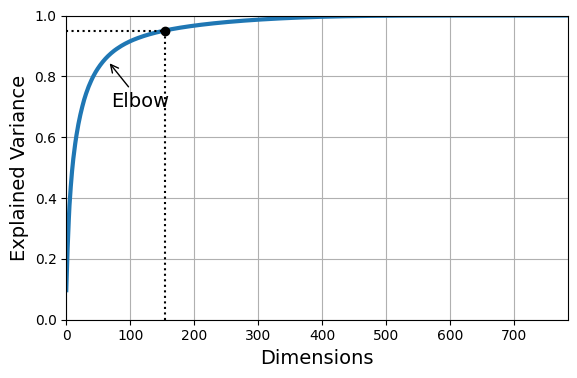

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 784, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)
save_fig("explained_variance_plot")
plt.show()

**Exemplo 1 → Utilizando RandomizedSearchCV**

Isso será visto com mais detalhes no próximo semestre, mas o RandomizedSearchCV é um um algoritmo que busca por hiperparâmetros ideais testando combinações aleatórias + validação cruzada.

Aqui o objetivo é identificar a melhor combinação de parâmetros para o PCA.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])},
                   random_state=42)

In [34]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


**Exemplo 2 → Utilizando GridSearchCV**

Isso será visto com mais detalhes no próximo semestre, mas o GridSearchCV é um um algoritmo que faz uma busca exaustiva: ele testa todas as combinações possíveis dos hiperparâmetros definidos.

O GridSearch é mais preciso que o RandomizedSearch, porém, tem um maior custo computacional.

In [35]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

clf = make_pipeline(PCA(random_state=42), SGDClassifier())
param_grid = {"pca__n_components": np.arange(10, 80)}
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X_train[:1000], y_train[:1000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                       ('sgdclassifier', SGDClassifier())]),
             param_grid={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])})

In [37]:
grid_search.best_params_

{'pca__n_components': np.int64(67)}

## PCA para Compressão

Comparando as imagens Originais vs PCA

In [39]:
pca = PCA(0.95)
X_reduced = pca.fit_transform(X_train, y_train)

In [40]:
X_recovered = pca.inverse_transform(X_reduced)

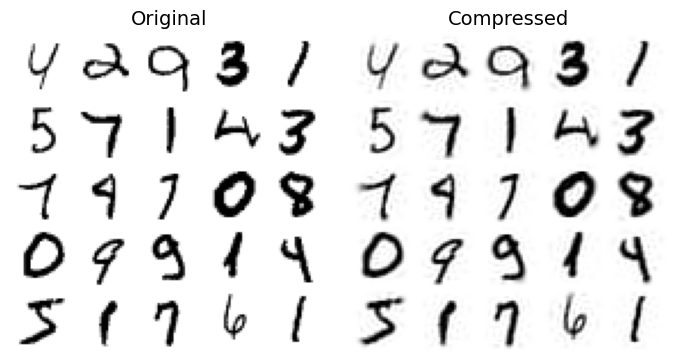

In [42]:
plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

save_fig("mnist_compression_plot")

### FIM DA 3ª DA DEMONSTRAÇÃO - voltar aos slides

# Exercícios

Este exercício deve ser desenvolvido utilizando o conjunto de dados do MNIST, que pode ser carregado através do código abaixo.

```
from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')
```

Este Dataset contém 70.000 amostras de números escritos a mão (do 0 ao 9), em sua Característica `data`, há um array de 784 posições, que representa uma imagem de 28 x 28 pixels (28 * 28 = 784). É possível visualizar a imagem através das seguintes instruções.

```
# Pegando a primeira imagem do Vetor X, que é um vetor de 784 posições,
# transformando em uma matriz de 28x28 e recriando a imagem
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X_mnist[0]
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()
```


1. Carregue o conjunto de dados MNIST (apresentado no capítulo 3) e divida-o em um conjunto de treinamento e um conjunto de teste (utilize as primeiras 60.000 instâncias para treinamento e as 10.000 restantes para teste).
Treine um classificador utilzando Floresta Aleatória no conjunto de dados e meça quanto tempo isso leva; em seguida, avalie o modelo resultante no conjunto de teste.

In [4]:
# RESOLUÇÃO EXERCÍCIO 1

#rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
#%time rnd_clf.fit(X_train, y_train)

2. Utiliza PCA para reduzir a dimensionalidade do dataset, com o objetivo de obter uma taxa de variância explicada de 95%. Treine um novo classificador utilzando Floresta Aleatória no conjunto de dados gerado pelo PCA e meça quanto tempo isso leva; em seguida, avalie o modelo resultante no conjunto de teste.

In [2]:
# RESOLUÇÃO EXERCÍCIO 2

3. Utilizando o Conjunto de Dados gerado pelo PCA, treine um novo Classificador utilizando SVM, com a classe `SGDClassifier` e meça quanto tempo isso leva; em seguida, avalie o modelo resultante no conjunto de teste.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 3

4. Compare o tempo de treinamento e a avaliação de cada um dos modelos. Isso trará uma visão mais clara a respeito do comportamento do PCA neste conjunto de dados.